In [1]:
# 1. Standard Library Imports
import os
import sys
import pickle
import warnings

# 2. Data Science & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn (Preprocessing & Metrics)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 4. PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Optional: Configuration
warnings.filterwarnings('ignore')

In [3]:


def describe_dataset(filepath):
    # 1. Load the dataset
    try:
        df = pd.read_csv(filepath)
        print(f"✅ Successfully loaded '{filepath}'")
    except FileNotFoundError:
        print(f"❌ Error: File '{filepath}' not found.")
        return

    print("\n" + "="*40)
    print(" 1. DATASET STRUCTURE")
    print("="*40)
    print(f"Rows:    {df.shape[0]}")
    print(f"Columns: {df.shape[1]}")
    print("\nColumn Names & Types:")
    print(df.dtypes)

    print("\n" + "="*40)
    print(" 2. MISSING VALUES")
    print("="*40)
    # Shows count of missing values per column (only showing columns that have missing data)
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("Great! No missing values detected.")
    else:
        print(missing[missing > 0])

    print("\n" + "="*40)
    print(" 3. STATISTICAL SUMMARY (Numerical)")
    print("="*40)
    # Transpose (.T) makes it easier to read if you have many columns
    print(df.describe().T)

    print("\n" + "="*40)
    print(" 4. CATEGORICAL SUMMARY")
    print("="*40)
    # Check number of unique values in text columns
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        for col in cat_cols:
            unique_count = df[col].nunique()
            print(f"{col}: {unique_count} unique values")
            # Print top 3 most frequent categories
            print(f"   Top 3: {df[col].value_counts().nlargest(3).index.tolist()}\n")
    else:
        print("No categorical columns found.")

    print("\n" + "="*40)
    print(" 5. DATA PREVIEW")
    print("="*40)
    print(df.head())

if __name__ == "__main__":
    # Replace with your actual file name
    describe_dataset('stratquest_dataset.csv')

✅ Successfully loaded 'stratquest_dataset.csv'

 1. DATASET STRUCTURE
Rows:    100000
Columns: 30

Column Names & Types:
Unnamed: 0                     int64
Distance_km                    int64
Scheduled_Departure           object
Scheduled_Arrival             object
Actual_Departure              object
Actual_Arrival                object
Scheduled_Travel_Time_min      int64
Actual_Travel_Time_min       float64
Departure_Delay_min          float64
Arrival_Delay_min              int64
Day_of_Week                   object
Month                          int64
Is_Holiday                    object
Festive_Period                object
Weather                       object
Temperature_C                 object
Track_Maintenance             object
Signal_Failure                object
Engine_Breakdown              object
Previous_Train_Delay_min       int64
Number_of_Stops                int64
Crew_Change                   object
Passenger_Load_pct           float64
Loco_Type                   

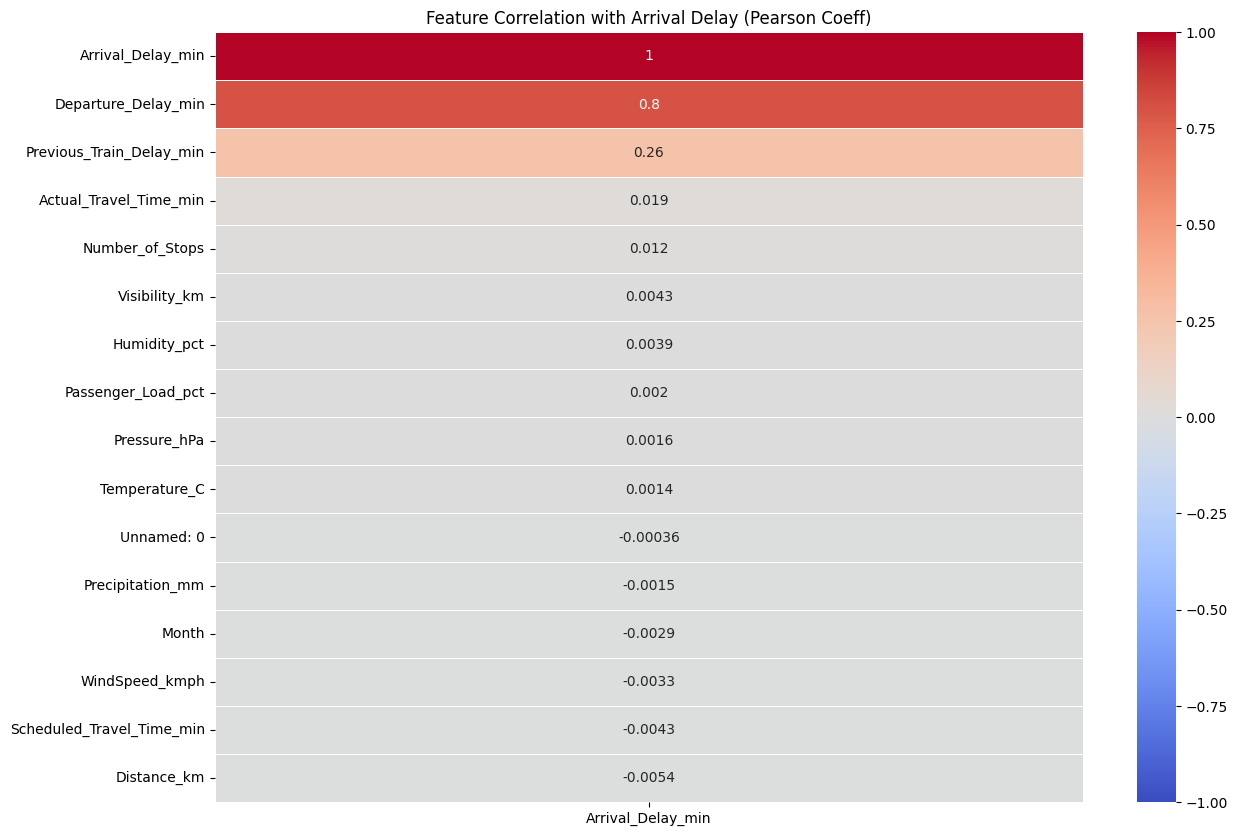

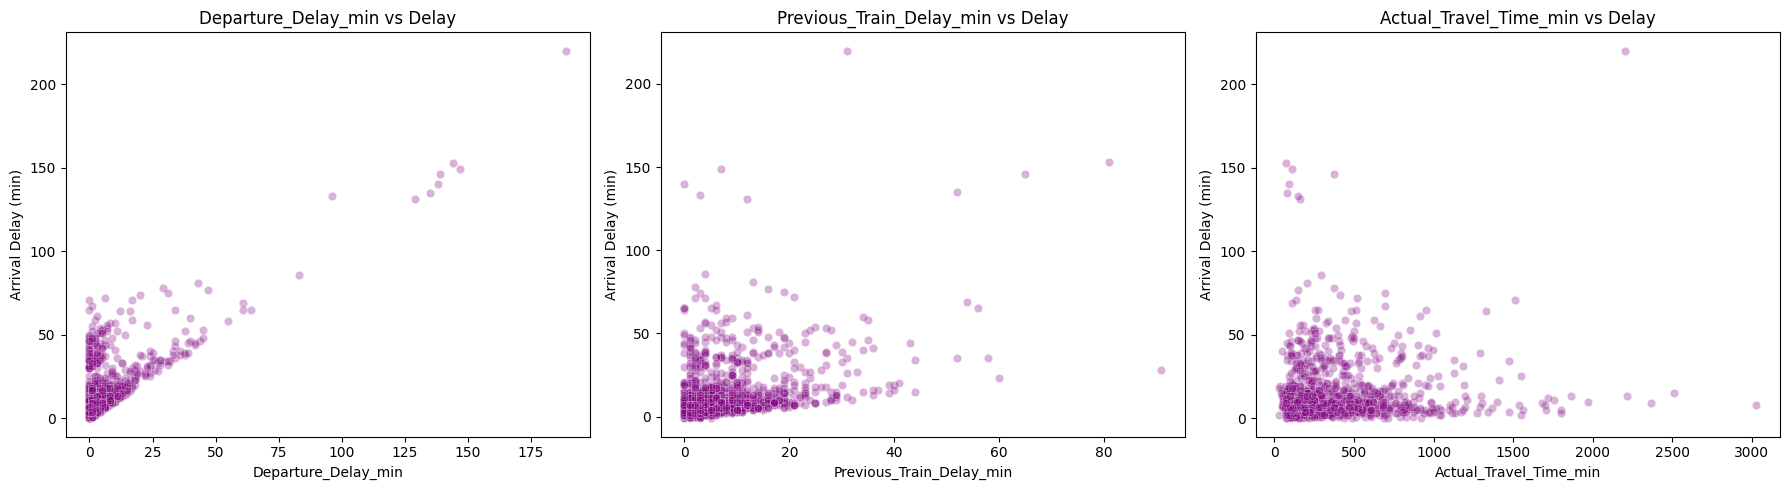

🧐 DATA INTELLIGENCE REPORT
Top 5 Drivers of Delay (Statistical Correlation):
                          Arrival_Delay_min
Arrival_Delay_min                  1.000000
Departure_Delay_min                0.800963
Previous_Train_Delay_min           0.261152
Actual_Travel_Time_min             0.019370
Number_of_Stops                    0.011753
Visibility_km                      0.004273


In [5]:
# 1. Load the Original Data
df = pd.read_csv('stratquest_dataset.csv', low_memory=False)

# 2. Clean numerical columns just like the preprocessor did (for fair comparison)
# (Simple cleanup to make sure correlation works)
target_col = 'Arrival_Delay_min'

# Convert text-based numbers (like "25C") to real floats
for col in ['Temperature_C', 'Humidity_pct']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Select only Numeric Columns for Correlation
numeric_df = df.select_dtypes(include=[np.number])

# --- VISUAL 1: The Correlation Matrix (Heatmap) ---
plt.figure(figsize=(14, 10))

# Calculate correlation
corr_matrix = numeric_df.corr()

# Filter to show only correlations with the Target (Arrival Delay)
# We sort them to see the "Most Important" features at the top
target_corr = corr_matrix[[target_col]].sort_values(by=target_col, ascending=False)

# Plot
sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation with Arrival Delay (Pearson Coeff)')
plt.show()

# --- VISUAL 2: The "Physics" Check (Scatter Plots) ---
# Let's see the relationships of the Top 3 drivers
top_drivers = target_corr.index[1:4] # Skip [0] because it's Arrival_Delay itself

plt.figure(figsize=(18, 5))
for i, feature in enumerate(top_drivers):
    plt.subplot(1, 3, i+1)
    # Use a sample (1000 rows) so the plot renders fast
    sns.scatterplot(x=df[feature].head(1000), y=df[target_col].head(1000), alpha=0.3, color='purple')
    plt.title(f'{feature} vs Delay')
    plt.xlabel(feature)
    plt.ylabel('Arrival Delay (min)')

plt.tight_layout()
plt.show()

# --- TEXT SUMMARY ---
print("="*40)
print("🧐 DATA INTELLIGENCE REPORT")
print("="*40)
print("Top 5 Drivers of Delay (Statistical Correlation):")
print(target_corr.head(6)) # Show top 5 + target

In [6]:
# Suppress pandas setting warnings
warnings.filterwarnings('ignore')

# Setting random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ==========================================
# 1. Advanced Feature Engineering & Preprocessing
# ==========================================

class RailwayPreprocessor:
    def __init__(self):
        self.label_encoders = {}
        self.scaler = StandardScaler()

        # Categorical columns
        self.cat_cols = [
            'Day_of_Week', 'Is_Holiday', 'Festive_Period', 'Weather',
            'Track_Maintenance', 'Signal_Failure', 'Engine_Breakdown',
            'Crew_Change', 'Loco_Type', 'WeatherCondition'
        ]

        # Columns containing text that needs cleaning (e.g. "25C", "80%")
        self.dirty_num_cols = ['Temperature_C', 'Humidity_pct']

        # Standard Numeric columns
        self.num_cols = [
            'Distance_km', 'Scheduled_Travel_Time_min', 'Departure_Delay_min',
            'Month', 'Previous_Train_Delay_min', 'Number_of_Stops',
            'Passenger_Load_pct', 'Precipitation_mm', 'WindSpeed_kmph',
            'Visibility_km', 'Pressure_hPa'
        ]
        # Generated cyclic features will be added to num_cols dynamically

    def _engineer_features(self, df):
        """Generates new features (Date/Time). Must be called in BOTH fit() and transform()."""
        df = df.copy()

        # DateTime Conversions & Cyclic Encoding
        if 'Scheduled_Departure' in df.columns:
            # Ensure it is datetime
            if not pd.api.types.is_datetime64_any_dtype(df['Scheduled_Departure']):
                df['Scheduled_Departure'] = pd.to_datetime(df['Scheduled_Departure'], errors='coerce')

            df['hour'] = df['Scheduled_Departure'].dt.hour
            df['dayofweek'] = df['Scheduled_Departure'].dt.dayofweek

            # Cyclic Encoding (Sin/Cos transforms)
            df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
            df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
            df['day_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
            df['day_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)

            # [NEW] RUSH HOUR FEATURE
            # Helps predict "silent" delays due to congestion (7-10 AM and 4-7 PM)
            df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 19) else 0)

        return df

    def clean_numeric_strings(self, df, col):
        """Removes symbols like '%' or 'C' and converts to float."""
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(r'[^\d.-]', '', regex=True)
            df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    def clean_physics(self, df):
        """Clips impossible values (negative rain, -60C temp, etc.)"""
        for col in ['Precipitation_mm', 'WindSpeed_kmph', 'Visibility_km']:
            if col in df.columns:
                df[col] = df[col].apply(lambda x: max(0, x))

        if 'Humidity_pct' in df.columns:
             df['Humidity_pct'] = df['Humidity_pct'].apply(lambda x: max(0, min(100, x)))

        if 'Pressure_hPa' in df.columns:
            df['Pressure_hPa'] = df['Pressure_hPa'].apply(lambda x: x if x > 0 else np.nan)

        if 'Temperature_C' in df.columns:
             df['Temperature_C'] = df['Temperature_C'].clip(lower=-40, upper=55)
        return df

    def fit(self, df):
        """Learns statistics (Mean/Std/Categories) from Training Data ONLY."""
        print("Fitting preprocessor...")

        # 1. Generate Features FIRST (so Scaler sees them)
        df = self._engineer_features(df)

        # 2. Add generated features to num_cols tracking
        new_feats = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_rush_hour']
        for f in new_feats:
            if f in df.columns and f not in self.num_cols:
                self.num_cols.append(f)

        # 3. Clean Dirty Strings
        for col in self.dirty_num_cols:
            df = self.clean_numeric_strings(df, col)
            if col not in self.num_cols:
                self.num_cols.append(col)

        # 4. Clean Physics
        df = self.clean_physics(df)

        # 5. Impute & Fit Scaler
        valid_cols = [c for c in self.num_cols if c in df.columns]
        for col in valid_cols:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)

        self.scaler.fit(df[valid_cols])

        # 6. Fit Label Encoders
        for col in self.cat_cols:
            if col in df.columns:
                le = LabelEncoder()
                df[col] = df[col].fillna('Unknown').astype(str)
                le.fit(df[col])
                self.label_encoders[col] = le
        return self

    def transform(self, df):
        """Applies transformations to Train/Val/Test data."""
        # 1. Generate Features (Must match fit!)
        df = self._engineer_features(df)

        # 2. Clean Strings
        for col in self.dirty_num_cols:
            df = self.clean_numeric_strings(df, col)

        # 3. Clean Physics
        df = self.clean_physics(df)

        # 4. Impute & Scale
        valid_cols = [c for c in self.num_cols if c in df.columns]
        for col in valid_cols:
            df[col] = df[col].fillna(0) # Fallback fill

        df[valid_cols] = self.scaler.transform(df[valid_cols])

        # 5. Label Encode
        for col in self.cat_cols:
            if col in df.columns:
                le = self.label_encoders[col]
                df[col] = df[col].fillna('Unknown').astype(str)
                # Map unknown labels to the first class (usually safer than crashing)
                known = set(le.classes_)
                df[col] = df[col].apply(lambda x: x if x in known else le.classes_[0])
                df[col] = le.transform(df[col])

        return df

# ==========================================
# 2. PyTorch Dataset & Model
# ==========================================

class RailwayDataset(Dataset):
    def __init__(self, df, cat_cols, num_cols, target_col):
        valid_num = [c for c in num_cols if c in df.columns]
        self.X_cat = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.X_num = torch.tensor(df[valid_num].values, dtype=torch.float32)
        # Reshape target to (N, 1)
        self.y = torch.tensor(df[target_col].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features, dropout_p=0.2):
        super().__init__()
        self.linear1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout_p)
        self.linear2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)

        self.shortcut = nn.Identity()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features),
                nn.BatchNorm1d(out_features)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.linear1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.dropout(out)
        out = self.linear2(out)
        out = self.bn2(out)
        out += residual
        out = self.act(out)
        return out

class RailwayDelayPredictor(nn.Module):
    def __init__(self, embedding_sizes, n_cont, hidden_dims=[512, 256, 128], dropout=0.2):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(ni, nf) for ni, nf in embedding_sizes])
        self.n_emb = sum(nf for ni, nf in embedding_sizes)
        self.emb_dropout = nn.Dropout(dropout)

        self.bn_cont = nn.BatchNorm1d(n_cont)
        self.input_dim = self.n_emb + n_cont

        layers = []
        in_dim = self.input_dim
        for h_dim in hidden_dims:
            layers.append(ResidualBlock(in_dim, h_dim, dropout))
            in_dim = h_dim

        self.deep_layers = nn.Sequential(*layers)
        self.head = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x_cat, x_cont):
        x = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat(x, 1)
        x = self.emb_dropout(x)
        x_cont = self.bn_cont(x_cont)
        x = torch.cat([x, x_cont], 1)
        x = self.deep_layers(x)
        return self.head(x)

# ==========================================
# 3. Main Engine
# ==========================================

def train_and_evaluate(filepath):
    # --- A. Load Data ---
    if not os.path.exists(filepath):
        print(f"Error: File '{filepath}' not found.")
        return None

    df = pd.read_csv(filepath)
    print(f"Loaded dataset with {df.shape} rows.")

    # --- B. Split Data ---
    # Sorting by date to prevent future data leaking into training
    if 'Scheduled_Departure' in df.columns:
        df['temp_date'] = pd.to_datetime(df['Scheduled_Departure'], errors='coerce')
        df = df.sort_values('temp_date').drop('temp_date', axis=1)

    n = len(df)
    train_end = int(n * 0.8)
    val_end = int(n * 0.9)

    train_raw = df.iloc[:train_end].copy()
    val_raw = df.iloc[train_end:val_end].copy()
    test_raw = df.iloc[val_end:].copy()

    # --- C. Fit & Transform Preprocessor ---
    preprocessor = RailwayPreprocessor()
    preprocessor.fit(train_raw) # FIT ONLY ON TRAIN

    train_df = preprocessor.transform(train_raw)
    val_df = preprocessor.transform(val_raw)
    test_df = preprocessor.transform(test_raw)

    # Target Column
    target_col = 'Arrival_Delay_min'

    # === [CRITICAL] LOG TRANSFORM TARGET ===
    # Compress target (0-1000 min) -> (0-7 log space) for stable training
    train_df[target_col] = np.log1p(train_df[target_col].clip(lower=0))
    val_df[target_col] = np.log1p(val_df[target_col].clip(lower=0))
    test_df[target_col] = np.log1p(test_df[target_col].clip(lower=0))
    print("✅ Applied Log-Transform to Target Variable")

    # --- D. Create Loaders (GPU Optimized) ---
    batch_size = 4096 # High batch size for GPU efficiency

    final_num_cols = [c for c in preprocessor.num_cols if c in train_df.columns]

    train_loader = DataLoader(
        RailwayDataset(train_df, preprocessor.cat_cols, final_num_cols, target_col),
        batch_size=batch_size, shuffle=True, pin_memory=True
    )
    val_loader = DataLoader(
        RailwayDataset(val_df, preprocessor.cat_cols, final_num_cols, target_col),
        batch_size=batch_size, pin_memory=True
    )
    test_loader = DataLoader(
        RailwayDataset(test_df, preprocessor.cat_cols, final_num_cols, target_col),
        batch_size=batch_size, pin_memory=True
    )

    # --- E. Initialize Model ---
    embedding_sizes = [(len(preprocessor.label_encoders[col].classes_) + 1,
                        min(50, (len(preprocessor.label_encoders[col].classes_) + 1) // 2))
                       for col in preprocessor.cat_cols]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")

    model = RailwayDelayPredictor(
        embedding_sizes=embedding_sizes,
        n_cont=len(final_num_cols),
        hidden_dims=[512, 256, 128],
        dropout=0.3
    ).to(device)

    # --- F. Training ---
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    # Strict patience to stop bouncing quickly
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1, verbose=True)

    epochs = 30
    best_val_loss = float('inf')

    print("\nStarting Training (Log-Space)...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x_cat, x_num, y in train_loader:
            x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(x_cat, x_num)
            loss = criterion(y_pred, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_cat, x_num, y in val_loader:
                x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
                y_pred = model(x_cat, x_num)
                val_loss += criterion(y_pred, y).item()

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Log-MSE: {avg_train_loss:.4f} | Val Log-MSE: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_railway_model.pth')

    # --- G. Final Test (Inverse Transform & Export) ---
    print("\nLoading best model for final evaluation...")
    model.load_state_dict(torch.load('best_railway_model.pth'))
    model.eval()

    predictions, actuals = [], []
    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
            y_pred = model(x_cat, x_num)

            # INVERSE TRANSFORM: Convert Log-Space back to Minutes
            pred_minutes = torch.expm1(y_pred).cpu().numpy().flatten()
            actual_minutes = torch.expm1(y).cpu().numpy().flatten()

            predictions.extend(pred_minutes)
            actuals.extend(actual_minutes)

    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)

    print("\n" + "="*30)
    print("FINAL TEST RESULTS (Real Minutes)")
    print("="*30)
    print(f"FINAL RMSE: {rmse:.2f} min")
    print(f"FINAL MAE:  {mae:.2f} min")
    print(f"FINAL R2:   {r2:.4f}")
    print("="*30)

    # Save Results to Excel
    results_df = pd.DataFrame({
        'Actual_Delay': actuals,
        'Predicted_Delay': predictions
    })
    results_df['Error'] = results_df['Actual_Delay'] - results_df['Predicted_Delay']
    results_df['Abs_Error'] = abs(results_df['Error'])

    # Join with raw test data for analysis
    test_raw_reset = test_raw.reset_index(drop=True)
    final_output = pd.concat([test_raw_reset, results_df], axis=1)

    try:
        final_output.to_excel('railway_model_results.xlsx', index=False)
        print("✅ Saved detailed results to 'railway_model_results.xlsx'")
    except ImportError:
        final_output.to_csv('railway_model_results.csv', index=False)
        print("✅ Saved detailed results to 'railway_model_results.csv'")

    # Return preprocessor so it can be pickled externally
    return preprocessor

if __name__ == "__main__":
    # 1. Run Pipeline
    dataset_path = 'stratquest_dataset.csv' # Ensure this matches your file
    final_preprocessor = train_and_evaluate(dataset_path)

    # 2. Save Preprocessor for Deployment
    if final_preprocessor is not None:
        with open('preprocessor.pkl', 'wb') as f:
            pickle.dump(final_preprocessor, f)
        print("✅ Saved 'preprocessor.pkl' for future use.")

Loaded dataset with (100000, 30) rows.
Fitting preprocessor...
✅ Applied Log-Transform to Target Variable
Training on: cpu


TypeError: __init__() got an unexpected keyword argument 'verbose'

In [18]:


# 1. Load Data
df = pd.read_csv('stratquest_dataset.csv')

# 2. Initialize Preprocessor
# (Make sure the RailwayPreprocessor class is defined in your notebook)
preprocessor = RailwayPreprocessor()

# 3. Fit it exactly as we did before (using 80% train split)
if 'Scheduled_Departure' in df.columns:
    df['temp_date'] = pd.to_datetime(df['Scheduled_Departure'], errors='coerce')
    df = df.sort_values('temp_date').drop('temp_date', axis=1)

n = len(df)
train_end = int(n * 0.8)
train_raw = df.iloc[:train_end].copy()

print("Refitting preprocessor...")
preprocessor.fit(train_raw)

# 4. Save
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

print("✅ Saved preprocessor.pkl (Ready for deployment)")

Refitting preprocessor...
Fitting preprocessor...
✅ Saved preprocessor.pkl (Ready for deployment)


Generating predictions for visualization...
Plotting results...


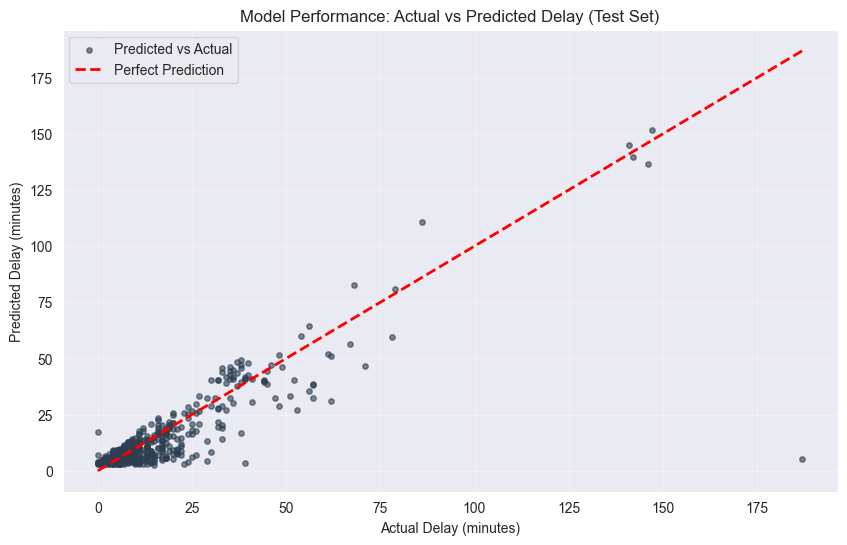

In [19]:


# 1. SETUP: Check for GPU and define paths
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset_path = 'stratquest_dataset.csv'
model_path = 'best_railway_model.pth'

# 2. DATA: Reload and Preprocess
# We assume 'preprocessor' is already available from the previous step.
# If not, we quickly re-fit it here to be safe.
if 'preprocessor' not in locals():
    print("⚠️ Preprocessor not found. Re-initializing...")
    df_raw = pd.read_csv(dataset_path)

    # Sort by date
    if 'Scheduled_Departure' in df_raw.columns:
        df_raw['temp_date'] = pd.to_datetime(df_raw['Scheduled_Departure'], errors='coerce')
        df_raw = df_raw.sort_values('temp_date').drop('temp_date', axis=1)

    # Re-fit
    n = len(df_raw)
    train_end = int(n * 0.8)
    preprocessor = RailwayPreprocessor() # Ensure class is defined
    preprocessor.fit(df_raw.iloc[:train_end])

# Load Test Data
df = pd.read_csv(dataset_path)
if 'Scheduled_Departure' in df.columns:
    df['temp_date'] = pd.to_datetime(df['Scheduled_Departure'], errors='coerce')
    df = df.sort_values('temp_date').drop('temp_date', axis=1)

n = len(df)
val_end = int(n * 0.9)
test_raw = df.iloc[val_end:].copy()

# Transform Test Data
test_df = preprocessor.transform(test_raw)
target_col = 'Arrival_Delay_min'
test_df[target_col] = np.log1p(test_df[target_col].clip(lower=0)) # Apply Log Transform

# Create Loader
batch_size = 4096
final_num_cols = [c for c in preprocessor.num_cols if c in test_df.columns]
test_loader = DataLoader(
    RailwayDataset(test_df, preprocessor.cat_cols, final_num_cols, target_col),
    batch_size=batch_size
)

# 3. MODEL: Re-Initialize and Load Weights
embedding_sizes = [(len(preprocessor.label_encoders[col].classes_) + 1,
                    min(50, (len(preprocessor.label_encoders[col].classes_) + 1) // 2))
                   for col in preprocessor.cat_cols]

model = RailwayDelayPredictor(
    embedding_sizes=embedding_sizes,
    n_cont=len(final_num_cols),
    hidden_dims=[512, 256, 128],
    dropout=0.0 # No dropout for inference
).to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 4. PREDICT: Generate 'actuals' and 'predictions'
print("Generating predictions for visualization...")
predictions, actuals = [], []

with torch.no_grad():
    for x_cat, x_num, y in test_loader:
        x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
        y_pred = model(x_cat, x_num)

        # Inverse Log Transform
        pred_minutes = torch.expm1(y_pred).cpu().numpy().flatten()
        actual_minutes = torch.expm1(y).cpu().numpy().flatten()

        predictions.extend(pred_minutes)
        actuals.extend(actual_minutes)

# 5. PLOT
print("Plotting results...")
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(actuals[:500], predictions[:500], alpha=0.6, color='#2c3e50', s=15, label='Predicted vs Actual')

# Perfect prediction line (Ideal Scenario)
min_val = min(min(actuals[:500]), min(predictions[:500]))
max_val = max(max(actuals[:500]), max(predictions[:500]))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Delay (minutes)')
plt.ylabel('Predicted Delay (minutes)')
plt.title('Model Performance: Actual vs Predicted Delay (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:

# 1. Create a DataFrame from your results lists
results_df = pd.DataFrame({
    'Actual_Delay_min': actuals,
    'Predicted_Delay_min': predictions
})

# 2. Add an "Error" column so you can sort by worst predictions
# Positive Error = Model under-predicted (Train was later than expected)
# Negative Error = Model over-predicted (Train was earlier than expected)
results_df['Error_Diff'] = results_df['Actual_Delay_min'] - results_df['Predicted_Delay_min']
results_df['Abs_Error'] = abs(results_df['Error_Diff'])

# 3. Save to Excel
# You might need to install openpyxl if you haven't: pip install openpyxl
try:
    results_df.to_excel('railway_model_results.xlsx', index=False)
    print("✅ Successfully saved 'railway_model_results.xlsx'")
    print(f"   Total rows saved: {len(results_df)}")
except ImportError:
    print("⚠️ Error: Missing library. Please run: pip install openpyxl")
    # Fallback to CSV if Excel fails
    results_df.to_csv('railway_model_results.csv', index=False)
    print("   Saved as .csv instead due to missing library.")

# 4. Preview the "Worst" Predictions (Top 5 largest errors)
print("\nTop 5 Worst Predictions (Outliers):")
print(results_df.sort_values('Abs_Error', ascending=False).head(5))

✅ Successfully saved 'railway_model_results.xlsx'
   Total rows saved: 10000

Top 5 Worst Predictions (Outliers):
      Actual_Delay_min  Predicted_Delay_min  Error_Diff   Abs_Error
3958        866.000000          1311.548706 -445.548706  445.548706
8533        198.000031             4.187672  193.812363  193.812363
8381        228.000000            42.498741  185.501251  185.501251
9024        187.000031             4.524608  182.475418  182.475418
8797        191.999985            10.028399  181.971588  181.971588


In [21]:
# 1. Combine the Feature Data (Test Set) with the Predictions
# We need to make sure indices align.
# 'test_df' from the training script is the transformed data.
# We need the RAW test data to see "Rain", "Station Name", etc.

# Re-load raw data to get the text columns back
df_full = pd.read_csv('stratquest_dataset.csv')

# Re-create the sort and split exactly as before
if 'Scheduled_Departure' in df_full.columns:
    df_full['temp_date'] = pd.to_datetime(df_full['Scheduled_Departure'], errors='coerce')
    df_full = df_full.sort_values('temp_date').drop('temp_date', axis=1)

n = len(df_full)
val_end = int(n * 0.9)
test_raw = df_full.iloc[val_end:].copy().reset_index(drop=True)

# 2. Add the Predictions to this raw data
# (Ensure 'predictions' and 'actuals' from the previous step are still in memory)
test_raw['AI_Predicted_Delay'] = predictions
test_raw['Actual_Delay'] = actuals
test_raw['Error'] = test_raw['Actual_Delay'] - test_raw['AI_Predicted_Delay']
test_raw['Abs_Error'] = abs(test_raw['Error'])

# 3. Sort by the biggest failures
failure_analysis = test_raw.sort_values('Abs_Error', ascending=False).head(20)

# 4. Save
failure_analysis.to_excel('debug_failures.xlsx', index=False)
print("✅ Saved 'debug_failures.xlsx'. Open this file to see the REAL reasons for the errors.")

✅ Saved 'debug_failures.xlsx'. Open this file to see the REAL reasons for the errors.


✅ Loaded data files.
🕵️ Detecting column names...
   Found Actual Delay column: 'Actual_Delay_min' -> Renaming to 'Actual_Delay'
   Found Prediction column: 'Predicted_Delay_min' -> Renaming to 'Predicted_Delay'


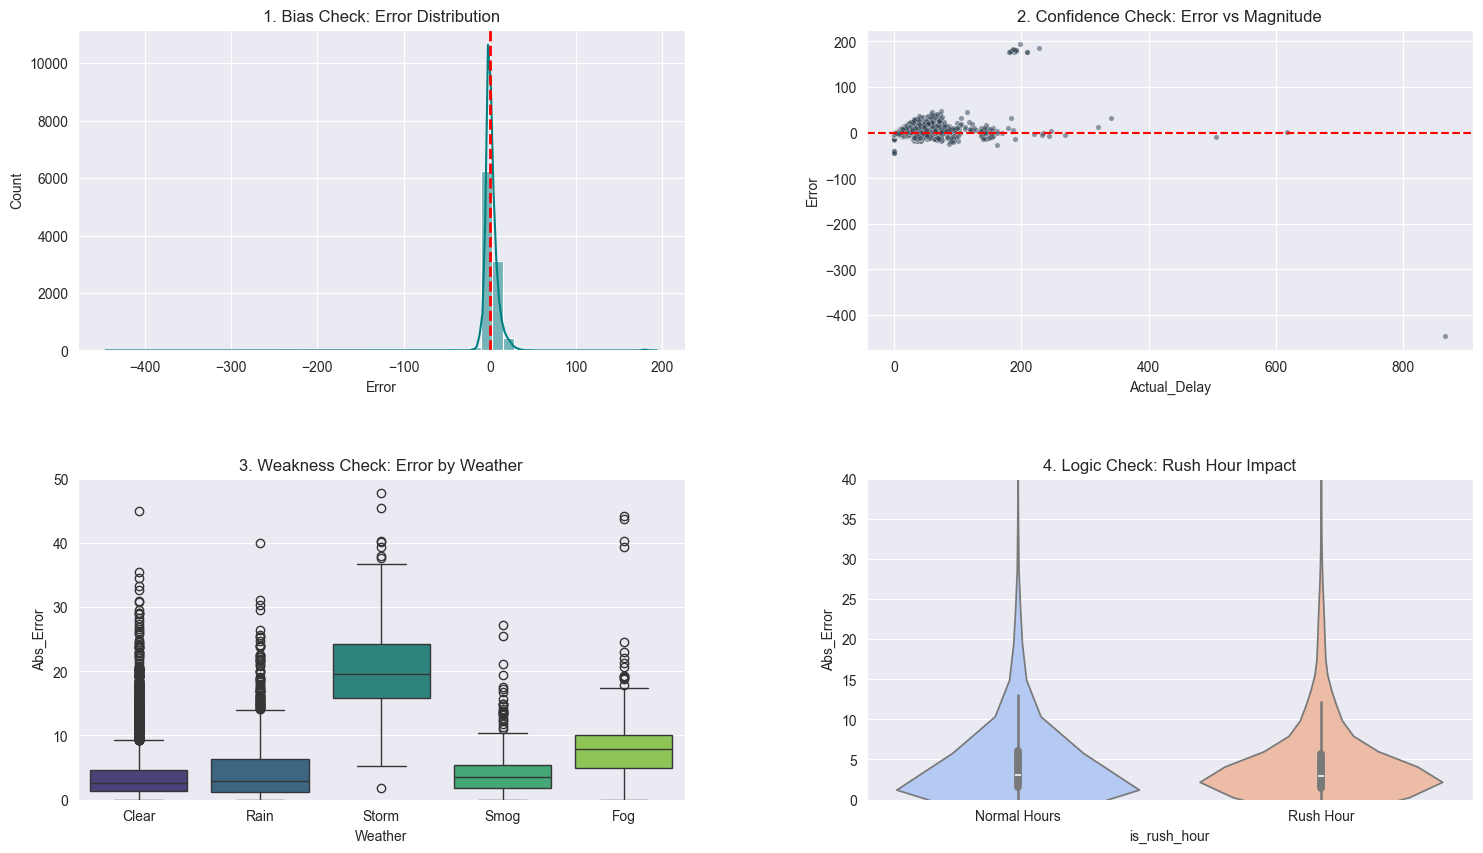


✅ Insights Generated Successfully (Clean Run).


In [22]:


# Suppress warnings for a clean output
warnings.filterwarnings('ignore')

# 1. Load Data
try:
    results_df = pd.read_excel('railway_model_results.xlsx')
    # [FIX] Added low_memory=False to handle mixed types cleanly
    original_df = pd.read_csv('stratquest_dataset.csv', low_memory=False)
    print("✅ Loaded data files.")
except FileNotFoundError:
    print("❌ Error: Missing files. Please run the training script first.")
    raise

# 2. Re-create the Test Set Split (To align rows)
if 'Scheduled_Departure' in original_df.columns:
    original_df['temp_date'] = pd.to_datetime(original_df['Scheduled_Departure'], errors='coerce')
    original_df = original_df.sort_values('temp_date').drop('temp_date', axis=1)

n = len(original_df)
val_end = int(n * 0.9)
test_data_with_features = original_df.iloc[val_end:].reset_index(drop=True)

# 3. Merge Features into Results
combined_df = pd.concat([test_data_with_features, results_df], axis=1)

# --- COLUMN DETECTIVE ---
print("🕵️ Detecting column names...")

# A. Find the "Actual" Column
possible_actuals = ['Actual_Delay', 'Actual_Delay_min', 'Arrival_Delay_min']
found_actual = next((c for c in possible_actuals if c in combined_df.columns), None)

if found_actual:
    print(f"   Found Actual Delay column: '{found_actual}' -> Renaming to 'Actual_Delay'")
    combined_df = combined_df.rename(columns={found_actual: 'Actual_Delay'})
else:
    print("   ⚠️ Actual Delay column missing. Calculating from raw data...")
    combined_df['Actual_Delay'] = combined_df['Actual_Arrival_Time_min'] - combined_df['Scheduled_Arrival_Time_min']

# B. Find the "Predicted" Column
possible_preds = ['Predicted_Delay', 'Predicted_Delay_min', 'AI_Predicted_Delay']
found_pred = next((c for c in possible_preds if c in combined_df.columns), None)

if found_pred:
    print(f"   Found Prediction column: '{found_pred}' -> Renaming to 'Predicted_Delay'")
    combined_df = combined_df.rename(columns={found_pred: 'Predicted_Delay'})

# C. Recalculate Error
if 'Actual_Delay' in combined_df.columns and 'Predicted_Delay' in combined_df.columns:
    combined_df['Error'] = combined_df['Actual_Delay'] - combined_df['Predicted_Delay']
    combined_df['Abs_Error'] = combined_df['Error'].abs()

# D. Create Rush Hour Feature
if 'is_rush_hour' not in combined_df.columns and 'Scheduled_Departure' in combined_df.columns:
    combined_df['temp_date'] = pd.to_datetime(combined_df['Scheduled_Departure'])
    combined_df['hour'] = combined_df['temp_date'].dt.hour
    combined_df['is_rush_hour'] = combined_df['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (16 <= x <= 19) else 0)

# 4. PLOTTING (Updated syntax to fix warnings)
plt.figure(figsize=(18, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot A: Bias
ax1 = plt.subplot(2, 2, 1)
sns.histplot(combined_df['Error'], kde=True, color='teal', bins=50, ax=ax1)
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.set_title('1. Bias Check: Error Distribution')

# Plot B: Magnitude
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(x=combined_df['Actual_Delay'], y=combined_df['Error'], alpha=0.5, color='#2c3e50', s=15, ax=ax2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_title('2. Confidence Check: Error vs Magnitude')

# Plot C: Weather (Fixed Palette Warning)
ax3 = plt.subplot(2, 2, 3)
if 'Weather' in combined_df.columns:
    # [FIX] Added hue='Weather' and legend=False
    sns.boxplot(x='Weather', y='Abs_Error', data=combined_df, hue='Weather', palette='viridis', legend=False, ax=ax3)
    ax3.set_title('3. Weakness Check: Error by Weather')
    ax3.set_ylim(0, 50)
else:
    ax3.text(0.5, 0.5, "Weather data missing", ha='center')

# Plot D: Rush Hour (Fixed Ticks Warning)
ax4 = plt.subplot(2, 2, 4)
# [FIX] Added hue='is_rush_hour' and set_xticks
sns.violinplot(x='is_rush_hour', y='Abs_Error', data=combined_df, hue='is_rush_hour', palette='coolwarm', legend=False, ax=ax4)
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Normal Hours', 'Rush Hour'])
ax4.set_title('4. Logic Check: Rush Hour Impact')
ax4.set_ylim(0, 40)

plt.show()

print("\n✅ Insights Generated Successfully (Clean Run).")


In [24]:
# Ensure we use the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def get_rmse(loader, model):
    """Helper to calculate error on the full dataset"""
    errors = []
    with torch.no_grad():
        for x_cat, x_num, y in loader:
            x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
            y_pred = model(x_cat, x_num)

            # Convert back to minutes (Inverse Log)
            pred_min = torch.expm1(y_pred).cpu().numpy().flatten()
            actual_min = torch.expm1(y).cpu().numpy().flatten()

            # Store squared errors
            errors.extend((pred_min - actual_min) ** 2)
    return np.sqrt(np.mean(errors))

print("📊 Calculating Baseline Error...")
baseline_rmse = get_rmse(test_loader, model)
print(f"✅ Baseline RMSE: {baseline_rmse:.4f} min")

📊 Calculating Baseline Error...
✅ Baseline RMSE: 10.8187 min


In [25]:
feature_importance = {}
print("🔄 Testing Feature Importance (this might take 1-2 minutes)...")

# We test all columns that the model actually uses
columns_to_test = preprocessor.cat_cols + [c for c in preprocessor.num_cols if c in test_df.columns]
target_col = 'Arrival_Delay_min' # Ensure this matches your target column name

for col in columns_to_test:
    # 1. Save original column data
    original_values = test_df[col].copy()

    # 2. SHUFFLE the column (Break the relationship)
    test_df[col] = np.random.permutation(test_df[col].values)

    # 3. Create a temporary loader with the shuffled data
    # We use the existing class definitions from your notebook
    final_num = [c for c in preprocessor.num_cols if c in test_df.columns]

    temp_loader = DataLoader(
        RailwayDataset(test_df, preprocessor.cat_cols, final_num, target_col),
        batch_size=4096, # Keep it fast
        shuffle=False
    )

    # 4. Measure new error
    shuffled_rmse = get_rmse(temp_loader, model)

    # 5. Importance = How much worse did it get?
    importance = shuffled_rmse - baseline_rmse
    feature_importance[col] = importance

    # 6. Restore original column for next loop (CRITICAL)
    test_df[col] = original_values

print("✅ Feature Importance Calculation Complete.")

🔄 Testing Feature Importance (this might take 1-2 minutes)...
✅ Feature Importance Calculation Complete.


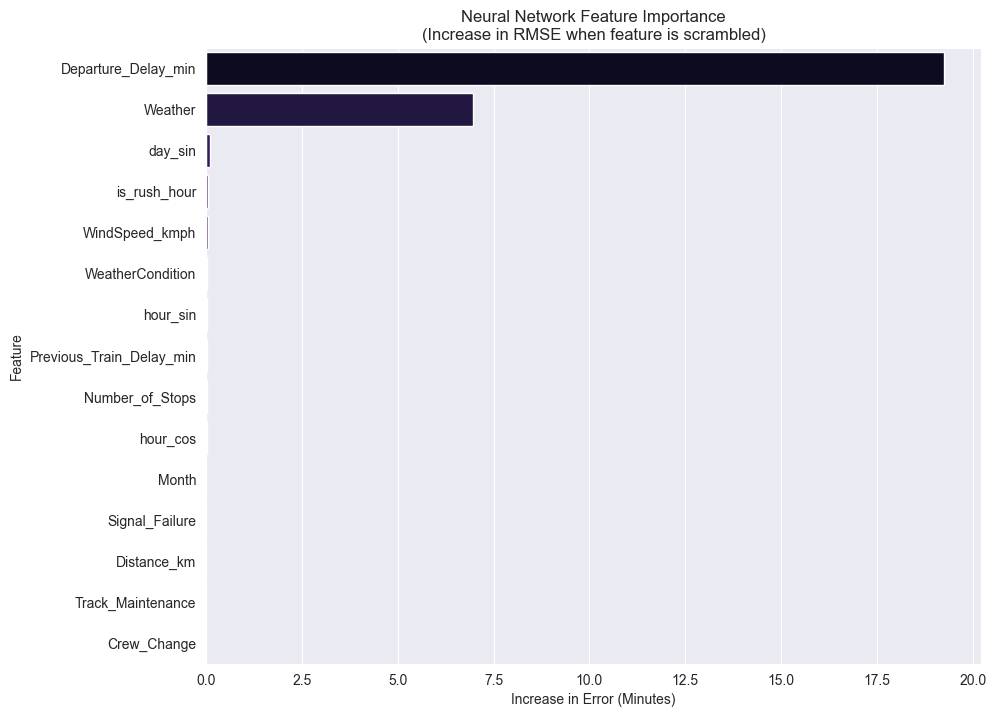


🏆 Top 5 Most Critical Features:
                Feature  Impact_min
12  Departure_Delay_min   19.258577
3               Weather    6.955521
23              day_sin    0.095850
25         is_rush_hour    0.053652
18       WindSpeed_kmph    0.051244


In [26]:
# Create DataFrame for plotting
importance_df = pd.DataFrame(list(feature_importance.items()), columns=['Feature', 'Impact_min'])

# Sort by impact (High impact = Most important)
importance_df = importance_df.sort_values(by='Impact_min', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Impact_min', y='Feature', data=importance_df, palette='magma')
plt.title('Neural Network Feature Importance\n(Increase in RMSE when feature is scrambled)')
plt.xlabel('Increase in Error (Minutes)')
plt.show()

# Print the Top 5 text summary
print("\n🏆 Top 5 Most Critical Features:")
print(importance_df[['Feature', 'Impact_min']].head(5))